In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [ ]:

torch.manual_seed(42)
X = torch.linspace(0, 10, 100).unsqueeze(1)
y = 2*X + 3 + torch.randn(X.size()) * 2


In [ ]:
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()

        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


In [ ]:
model = RegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [ ]:
epochs = 200
losses = []

for epoch in range(epochs):

    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 20/200, Loss: 6.7266
Epoch 40/200, Loss: 6.2077
Epoch 60/200, Loss: 5.7824
Epoch 80/200, Loss: 5.4339
Epoch 100/200, Loss: 5.1483
Epoch 120/200, Loss: 4.9143
Epoch 140/200, Loss: 4.7225
Epoch 160/200, Loss: 4.5653
Epoch 180/200, Loss: 4.4365
Epoch 200/200, Loss: 4.3309


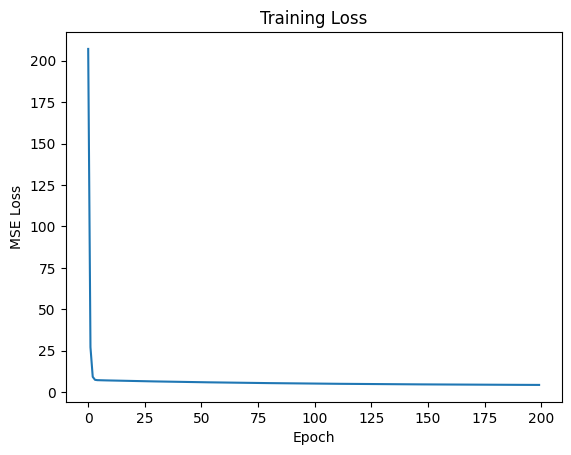

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.show()


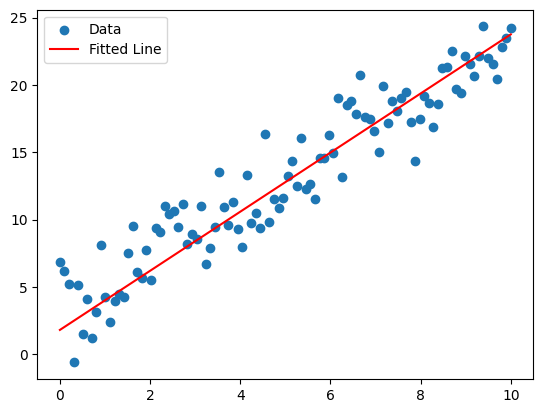

In [ ]:
predicted = model(X).detach()

plt.scatter(X, y, label="Data")
plt.plot(X, predicted, color='red', label="Fitted Line")
plt.legend()
plt.show()


In [ ]:
!pip install kaggle -q

import os, json
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

with open("kaggle (1).json", "r") as f:
    creds = json.load(f)
os.environ['KAGGLE_USERNAME'] = creds['username']
os.environ['KAGGLE_KEY'] = creds['key']

!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p data/
!unzip -oq data/new-plant-diseases-dataset.zip -d data/

root_dir = Path("data")
train_path = None
val_path = None
for p in root_dir.rglob("*"):
    if p.is_dir() and p.name.lower() == "train":
        train_path = p
    if p.is_dir() and p.name.lower() == "valid":
        val_path = p

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(root=str(train_path), transform=transform)
val_dataset   = datasets.ImageFolder(root=str(val_path), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(len(train_dataset), "training images")
print(len(val_dataset), "validation images")
print("Classes:", train_dataset.classes[:10], "...")


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.67G/2.70G [00:26<00:00, 141MB/s]
100% 2.70G/2.70G [00:26<00:00, 107MB/s]
70295 training images
17572 validation images
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight'] ...


In [ ]:
print(len(train_dataset), "training images")
print(len(val_dataset), "validation images")
print("Classes:", train_dataset.classes[:10], "...")


70295 training images
17572 validation images
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight'] ...


In [ ]:
print(transform)


Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


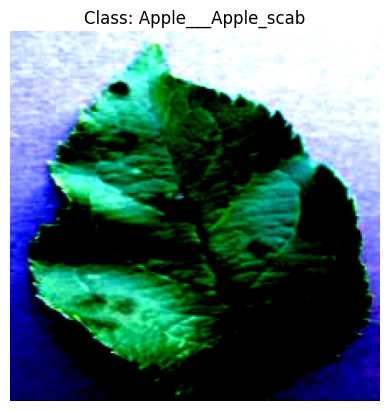

In [ ]:
image, label = train_dataset[0]
imshow(image, f"Class: {train_dataset.classes[label]}")


In [ ]:
images, labels = next(iter(train_loader))
print("Batch of images shape:", images.shape)
print("Batch of labels shape:", labels.shape)


Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])


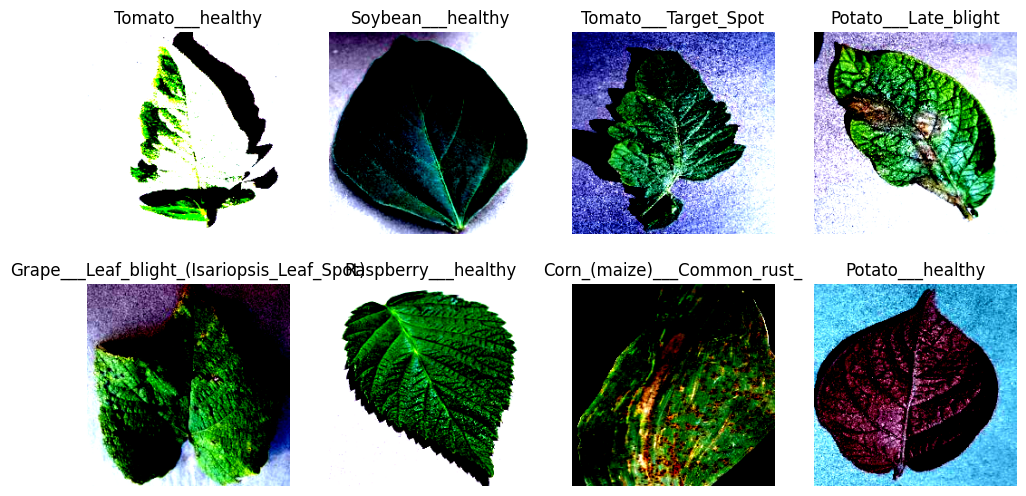

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    img = images[i].numpy().transpose((1, 2, 0))
    axes[i//4, i%4].imshow(img)
    axes[i//4, i%4].set_title(train_dataset.classes[labels[i]])
    axes[i//4, i%4].axis("off")
plt.show()


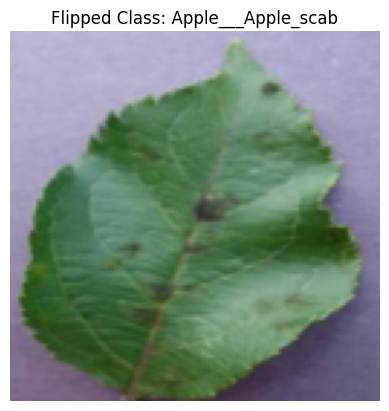

In [ ]:
import matplotlib.pyplot as plt


plt.imshow(image.permute(1, 2, 0))
plt.title(f"Flipped Class: {flipped_dataset.classes[label]}")
plt.axis("off")
plt.show()


In [ ]:
from torch.utils.data import DataLoader


temp_dataset = datasets.ImageFolder(root=str(train_path),
                                    transform=transforms.ToTensor())
loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)


mean = 0.0
std = 0.0
for images, _ in loader:
    mean += images.mean([0, 2, 3])
    std  += images.std([0, 2, 3])
mean /= len(loader)
std /= len(loader)

print("Calculated mean:", mean)
print("Calculated std:", std)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])


train_dataset = datasets.ImageFolder(root=str(train_path), transform=transform)
val_dataset   = datasets.ImageFolder(root=str(val_path), transform=transform)


Calculated mean: tensor([0.4757, 0.5001, 0.4264])
Calculated std: tensor([0.2070, 0.1838, 0.2215])


In [ ]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')


drive_base = "/content/drive/MyDrive/kaggle_datasets"
drive_dataset_path = f"{drive_base}/plant_disease"
drive_kaggle_json = f"{drive_base}/kaggle.json"
local_dataset_path = "/content/plant_disease"


if not os.path.exists(drive_kaggle_json):
    print("⚠️ kaggle.json not found in Drive. Please upload it now.")
    from google.colab import files
    uploaded = files.upload()
    os.makedirs(drive_base, exist_ok=True)


    uploaded_filename = list(uploaded.keys())[0]
    shutil.move(uploaded_filename, "kaggle.json")
    shutil.copy("kaggle.json", drive_kaggle_json)
    print("kaggle.json saved to Drive")

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy(drive_kaggle_json, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)


if not os.path.exists(drive_dataset_path):
    print("Downloading dataset from Kaggle...")
    !kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p /content/
    !unzip -q /content/new-plant-diseases-dataset.zip -d {drive_dataset_path}
    print(" Dataset downloaded and saved to Drive")
else:
    print(" Dataset already in Drive")


if not os.path.exists(local_dataset_path):
    shutil.copytree(drive_dataset_path, local_dataset_path)
    print("📂 Dataset copied to runtime")
else:
    print("📂 Dataset already available in runtime")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset already in Drive
📂 Dataset already available in runtime


In [ ]:
# Colab-ready fast training with pretrained EfficientNet-B0
# - Auto rsync Drive -> /content/train_local
# - Safe loader + Dataset-level filtering
# - torch.amp + channels_last + TF32
# - EfficientNet_B0 pretrained, partial freeze for speed
# - IMG_SIZE=192, NUM_WORKERS=2, dynamic batch size

import os, sys, subprocess
from pathlib import Path
from typing import Optional, Tuple, Any
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, datasets, models
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm
from PIL import Image, ImageFile

# ----------------------------
# Config
# ----------------------------
IMG_SIZE = 192
BATCH_SIZE_TRY = [96, 64, 48]     # try in order; pick first that fits
NUM_EPOCHS = 10                   # fewer epochs thanks to pretrained
LR = 3e-4                         # lower LR for fine-tuning
WEIGHT_DECAY = 1e-4
TRAIN_VAL_SPLIT = 0.9
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# ----------------------------
# Paths
# ----------------------------
DRIVE_TRAIN = "/content/drive/MyDrive/kaggle_datasets/plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
LOCAL_TRAIN = "/content/train_local"

def fail(msg): print(msg); sys.exit(1)

def rsync_copy(src: str, dst: str):
    Path(dst).mkdir(parents=True, exist_ok=True)
    cmd = ["rsync", "-a", "--info=progress2", f"{src.rstrip('/')}/", f"{dst.rstrip('/')}/"]
    print("Copying dataset to local SSD with rsync:\n ", " ".join(cmd))
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout: print(line, end="")
    if p.wait() != 0: fail("rsync failed")

def looks_like_imagefolder_train(train_dir: Path) -> bool:
    if not train_dir.exists() or not train_dir.is_dir(): return False
    class_dirs = [d for d in train_dir.iterdir() if d.is_dir()]
    if len(class_dirs) < 2: return False
    IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".gif",".webp"}
    for d in class_dirs:
        for f in d.rglob("*"):
            if f.is_file() and f.suffix.lower() in IMG_EXTS:
                return True
    return False

def ensure_local_mirror(src_dir: str, dst_dir: str):
    if not Path(src_dir).exists(): fail(f"Source train path does not exist: {src_dir}")
    if not looks_like_imagefolder_train(Path(dst_dir)):
        rsync_copy(src_dir, dst_dir)

ensure_local_mirror(DRIVE_TRAIN, LOCAL_TRAIN)
DATA_ROOT = LOCAL_TRAIN if looks_like_imagefolder_train(Path(LOCAL_TRAIN)) else DRIVE_TRAIN
if not looks_like_imagefolder_train(Path(DATA_ROOT)): fail("No valid multi-class train folder found.")
print(f"Using dataset root: {DATA_ROOT}")

# ----------------------------
# Safe loader + dataset
# ----------------------------
ImageFile.LOAD_TRUNCATED_IMAGES = True

def pil_safe_loader(path: str) -> Optional[Image.Image]:
    try:
        with Image.open(path) as img:
            return img.convert("RGB")
    except Exception:
        return None

class SafeImageFolder(Dataset):
    def __init__(self, root: str, transform=None):
        self.base = datasets.ImageFolder(root, transform=None, loader=pil_safe_loader)
        self.transform = transform
        self.samples = []
        skipped = 0
        for p, y in self.base.samples:
            im = pil_safe_loader(p)
            if im is None: skipped += 1
            else: self.samples.append((p, y))
        self.class_to_idx = self.base.class_to_idx
        self.classes = self.base.classes
        if skipped: print(f"Filtered {skipped} unreadable images up-front.")
    def __len__(self): return len(self.samples)
    def __getitem__(self, i: int) -> Tuple[Any, int]:
        p, y = self.samples[i]
        im = pil_safe_loader(p) or Image.new("RGB", (IMG_SIZE, IMG_SIZE))
        if self.transform is not None: im = self.transform(im)
        return im, y


# Transforms (pretrained-friendly)

train_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])


# Datasets and split

full_train_raw = SafeImageFolder(DATA_ROOT, transform=train_tf)
num_classes = len(full_train_raw.classes)
print(f"Found {len(full_train_raw)} images belonging to {num_classes} classes")

train_size = int(len(full_train_raw) * TRAIN_VAL_SPLIT)
val_size = len(full_train_raw) - train_size
train_subset, val_subset = random_split(full_train_raw, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Validation subset with val transforms (reloading by path)
class SubsetVal(Dataset):
    def __init__(self, base_subset: torch.utils.data.Subset, root_dataset: SafeImageFolder, transform):
        self.indices = base_subset.indices
        self.root = root_dataset
        self.transform = transform
        self.classes = root_dataset.classes
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        p, y = self.root.samples[self.indices[idx]]
        im = pil_safe_loader(p) or Image.new("RGB", (IMG_SIZE, IMG_SIZE))
        im = self.transform(im)
        return im, y

val_dataset = SubsetVal(val_subset, full_train_raw, val_tf)

# Select batch size that fits
def pick_batch_size(candidates):
    for bs in candidates:
        try:
            x = torch.empty(bs, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
            del x
            return bs
        except Exception:
            continue
    return candidates[-1]

BATCH_SIZE = pick_batch_size(BATCH_SIZE_TRY)
print("Using batch size:", BATCH_SIZE)

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0 and PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0 and PIN_MEMORY,
)


# Model: EfficientNet-B0 pretrained

weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights).to(DEVICE)
model = model.to(memory_format=torch.channels_last)

# Replace classifier
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, num_classes).to(DEVICE)

# Freeze early layers for speed; keep last two stages trainable
for name, param in model.features.named_parameters():
    param.requires_grad = False
for name, module in list(model.features.named_children())[-2:]:
    for p in module.parameters():
        p.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)

# OneCycleLR for quick convergence in few epochs
steps_per_epoch = max(1, len(train_loader))
scheduler = OneCycleLR(optimizer, max_lr=LR, epochs=NUM_EPOCHS, steps_per_epoch=steps_per_epoch)

use_cuda_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_cuda_amp)

def accuracy(logits, target):
    return (logits.argmax(dim=1) == target).float().mean().item()


# Train

best_val_acc = 0.0
best_path = None
start = datetime.now()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    run_loss = 0.0; run_acc = 0.0; nb = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]", unit="batch")
    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_cuda_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        run_loss += loss.item()
        run_acc += accuracy(logits, labels)
        nb += 1
        pbar.set_postfix(loss=f"{run_loss/nb:.4f}", acc=f"{run_acc/nb:.4f}")

    # Val
    model.eval(); v_loss = 0.0; v_acc = 0.0; vb = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]", unit="batch"):
            images = images.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_cuda_amp):
                logits = model(images)
                loss = criterion(logits, labels)
            v_loss += loss.item()
            v_acc += accuracy(logits, labels)
            vb += 1

    t_loss = run_loss/max(1,nb); t_acc = run_acc/max(1,nb)
    val_loss = v_loss/max(1,vb); val_acc = v_acc/max(1,vb)
    print(f"\nEpoch {epoch} summary: Train loss {t_loss:.4f} acc {t_acc:.4f} | Val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_path = os.path.join(SAVE_DIR, f"effb0_best_epoch{epoch}_acc{best_val_acc:.4f}.pt")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": best_val_acc,
            "classes": full_train_raw.classes,
        }, best_path)
        print("Saved:", best_path)

elapsed = datetime.now() - start
print(f"Training finished. Best val acc: {best_val_acc:.4f}. Elapsed: {elapsed}")
if best_path:
    print(f"To load:\n ckpt = torch.load('{best_path}', map_location=DEVICE)\n model.load_state_dict(ckpt['model_state'])")


Using dataset root: /content/train_local
Filtered 1 unreadable images up-front.
Found 23167 images belonging to 13 classes
Using batch size: 96
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 81.4MB/s]
Epoch 1/10 [Val]: 100%|██████████| 25/25 [01:47<00:00,  4.28s/batch]



Epoch 1 summary: Train loss 2.0610 acc 0.4520 | Val loss 0.8038 acc 0.8777
Saved: checkpoints/effb0_best_epoch1_acc0.8777.pt


Epoch 2/10 [Val]: 100%|██████████| 25/25 [01:46<00:00,  4.26s/batch]



Epoch 2 summary: Train loss 0.5105 acc 0.8840 | Val loss 0.0986 acc 0.9707
Saved: checkpoints/effb0_best_epoch2_acc0.9707.pt


...


Epoch 8 summary: Train loss 0.0736 acc 0.9754 | Val loss 0.0222 acc 0.9886


Epoch 9/10 [Val]: 100%|██████████| 25/25 [01:44<00:00,  4.17s/batch]



Epoch 9 summary: Train loss 0.0692 acc 0.9772 | Val loss 0.0217 acc 0.9894


Epoch 10/10 [Val]: 100%|██████████| 25/25 [01:42<00:00,  4.12s/batch]


Epoch 10 summary: Train loss 0.0693 acc 0.9768 | Val loss 0.0199 acc 0.9917
Saved: checkpoints/effb0_best_epoch10_acc0.9917.pt
Training finished. Best val acc: 0.9917. Elapsed: 3:35:41.390815
To load:
 ckpt = torch.load('checkpoints/effb0_best_epoch10_acc0.9917.pt', map_location=DEVICE)
 model.load_state_dict(ckpt['model_state'])


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, torch
SAVE_DIR = "/content/drive/MyDrive/colab_models/plant_effb0"
os.makedirs(SAVE_DIR, exist_ok=True)

# after computing best_path or finishing training, write a single canonical file:
ckpt_path = os.path.join(SAVE_DIR, "effb0_best.pt")
torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "val_acc": best_val_acc,
    "classes": full_train_raw.classes,                 # already in project.py
    "img_size": IMG_SIZE,                              # add for reproducibility
    "normalize": {"mean":[0.485,0.456,0.406], "std":[0.229,0.224,0.225]},  # val_tf stats
}, ckpt_path)
print("Saved:", ckpt_path)


Saved: /content/drive/MyDrive/colab_models/plant_effb0/effb0_best.pt


In [ ]:
!ls -lh /content/drive/MyDrive/colab_models/plant_effb0


total 25M
-rw------- 1 root root 25M Sep 26 16:34 effb0_best.pt


In [ ]:
!pip freeze > /content/drive/MyDrive/colab_models/plant_effb0/requirements.txt


In [ ]:
# ===== Print Top-5 predictions robustly (works after reopening Colab) =====
from google.colab import drive
drive.mount('/content/drive')

import os, re, torch, torch.nn as nn
from torchvision import models, transforms
from PIL import Image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths (edit IMAGE_PATH or FOLDER_PATH as needed)
CKPT_PATH  = "/content/drive/MyDrive/colab_models/plant_effb0/effb0_best.pt"
IMAGE_PATH = "/content/drive/MyDrive/sample.jpg"              # put a real image here
FOLDER_PATH = "/content/drive/MyDrive/predict_images"         # optional folder

# Load checkpoint on current device
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

# Rebuild EfficientNet-B0 head and load weights strictly
num_classes = len(ckpt["classes"])
model = models.efficientnet_b0(weights=None)
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, num_classes)
model.load_state_dict(ckpt["model_state"], strict=True)
model.to(DEVICE).eval()

# Preprocessing from saved metadata (fallback to ImageNet stats)
IMG_SIZE = int(ckpt.get("img_size", 224))
norm = ckpt.get("normalize", {})
mean = norm.get("mean", [0.485, 0.456, 0.406])
std  = norm.get("std",  [0.229, 0.224, 0.225])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

@torch.no_grad()
def topk_labels(image_path: str, k: int = 5):
    img = Image.open(image_path).convert("RGB")
    x = val_tf(img).unsqueeze(0).to(DEVICE)
    probs = torch.softmax(model(x), dim=1)[0]
    k = min(k, probs.numel())
    conf, idxs = torch.topk(probs, k)
    labels = [ckpt["classes"][int(i)] for i in idxs]
    return [(labels[i], float(conf[i])) for i in range(k)]

def iter_folder_images_case_insensitive(folder):
    pat = re.compile(r'.*\.(jpg|jpeg|png|bmp|webp)$', re.IGNORECASE)
    for base, _, files in os.walk(folder):
        for name in sorted(files):
            if pat.match(name):
                yield os.path.join(base, name)

# Resolve an image to run
resolved = None
if IMAGE_PATH and os.path.isfile(IMAGE_PATH):
    resolved = IMAGE_PATH
elif os.path.isdir(FOLDER_PATH):
    for fp in iter_folder_images_case_insensitive(FOLDER_PATH):
        resolved = fp
        break
if resolved is None:
    # Fallback: upload one image interactively
    from google.colab import files
    print("Pick an image to upload…")
    up = files.upload()
    if up:
        first_name = next(iter(up.keys()))
        resolved = "/content/" + first_name

if resolved is None or not os.path.isfile(resolved):
    raise FileNotFoundError("No image found. Set IMAGE_PATH to a valid file, put files in FOLDER_PATH, or upload one.")

# Print top-5 predictions
top5 = topk_labels(resolved, k=5)
print(f"Top-5 for: {resolved}")
for r, (lbl, p) in enumerate(top5, start=1):
    print(f"{r}. {lbl:30s} {p:.4f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pick an image to upload…


Saving test2.webp to test2.webp
Top-5 for: /content/test2.webp
1. Blueberry___healthy            0.9927
2. Grape___Black_rot              0.0043
3. Apple___healthy                0.0006
4. Apple___Apple_scab             0.0006
5. Cherry_(including_sour)___Powdery_mildew 0.0006
